In [1]:
import sys
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm.auto import tqdm

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import ModelConfig, DEFAULT_CONFIG, PROJECT_ROOT
from model import ADModel

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TRAIN_MODEL = "ADReSS"
BEST_RANDOM_SEED = 168
TRAIN_MODEL_ACC = 84.38

# Define up to 4 test datasets, leave empty string "" if not needed
TEST_DATASETS = ["Pitt", "Lu"]#, "ADReSSo", "ADReSS-M"]
COLORS = ['#F5A623', '#27F5EE', '#B727F5', '#9F5EDE', '#50E3C2', '#4A90E2']

In [3]:
BEST_MODEL_PATH = PROJECT_ROOT / f"models/{TRAIN_MODEL}_xlsr_multi_seed/seed_{BEST_RANDOM_SEED}/best.ckpt"

# Filter out empty datasets and build valid configuration list
valid_datasets = []

for dataset_name in TEST_DATASETS:
    if dataset_name and dataset_name.strip():
        config = {
            'name': dataset_name,
            'audio_dir': PROJECT_ROOT / f"data/raw/{dataset_name}",
            'features_dir': PROJECT_ROOT / f"data/processed/{dataset_name}_xlsr_features",
            'csv_path': PROJECT_ROOT / f"data/processed/{dataset_name}-xlsr-test.csv",
            'feature_dir_name': f"{dataset_name}_xlsr_features"
        }
        valid_datasets.append(config)

print(f"Number of valid test datasets: {len(valid_datasets)}")
for i, ds in enumerate(valid_datasets, 1):
    print(f"  {i}. {ds['name']}")

Number of valid test datasets: 2
  1. Pitt
  2. Lu


In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


## Step 1: Create test CSV files for datasets

In [5]:
for dataset_config in valid_datasets:
    dataset_name = dataset_config['name']
    audio_dir = dataset_config['audio_dir']
    csv_path = dataset_config['csv_path']
    features_dir = dataset_config['features_dir']
    feature_dir_name = dataset_config['feature_dir_name']
    
    features_dir.mkdir(parents=True, exist_ok=True)
    
    # Collect audio files from test dataset
    test_samples = []
    
    for label_dir in ["Control", "Dementia"]:
        label_audio_dir = audio_dir / label_dir
        if not label_audio_dir.exists():
            print(f"⚠️ Directory does not exist: {label_audio_dir}")
            continue
        
        label = 0 if label_dir == "Control" else 1
        
        audio_files = list(label_audio_dir.glob("*.wav")) + list(label_audio_dir.glob("*.mp3"))
        for audio_file in sorted(audio_files):
            session_id = audio_file.stem
            feature_path = f"{feature_dir_name}/{session_id}.xlsr.pt"
            
            test_samples.append({
                "session_id": session_id,
                "xlsr_path": feature_path,
                "ad": label,
                "audio_path": str(audio_file.relative_to(PROJECT_ROOT))
            })

    # Create CSV
    test_df = pd.DataFrame(test_samples)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    test_df.to_csv(csv_path, index=False)

    print(f"✅ {dataset_name} dataset CSV created: {csv_path}")
    print(f"   Total samples: {len(test_df)}")
    print(f"   Control: {(test_df['ad'] == 0).sum()}")
    print(f"   Dementia: {(test_df['ad'] == 1).sum()}")

✅ Pitt dataset CSV created: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Pitt-xlsr-test.csv
   Total samples: 551
   Control: 242
   Dementia: 309
✅ Lu dataset CSV created: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/data/processed/Lu-xlsr-test.csv
   Total samples: 53
   Control: 25
   Dementia: 28


## Step 2: Extract XLSR features

In [6]:
from model import SSLModel
from extract_XLSR_feature import extract_features_from_csv

ssl_model = SSLModel(device, freeze_xlsr=True)

for dataset_config in valid_datasets:
    dataset_name = dataset_config['name']
    csv_path = dataset_config['csv_path']
    audio_dir = dataset_config['audio_dir']
    features_dir = dataset_config['features_dir']
    
    print()
    print("="*60)
    print(f"Extracting XLSR features for {dataset_name}...")
    print("="*60) 
    
    extract_features_from_csv(
        csv_path=csv_path,
        split_name=f"{dataset_name} Set",
        raw_audio_dir=audio_dir,
        xlsr_features_dir=features_dir,
        device=device,
        ssl_model=ssl_model,
    )


XLSR:Using original XLSR model


/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)



Extracting XLSR features for Pitt...

============= Extracting XLSR features for Pitt Set =============
551 Audio Files


Extracting Pitt Set: 100%|██████████| 551/551 [00:00<00:00, 31223.81it/s]


Successfully extracted: 0
Already exists (skipped): 551
Errors: 0
Total: 551

Extracting XLSR features for Lu...

============= Extracting XLSR features for Lu Set =============
53 Audio Files


Extracting Lu Set: 100%|██████████| 53/53 [00:00<00:00, 38768.42it/s]

Successfully extracted: 0
Already exists (skipped): 53
Errors: 0
Total: 53


## Step 3: Load the trained model


In [7]:
# Load the best model
print(f"Loading model: {BEST_MODEL_PATH}")

xlsr_config = ModelConfig(
    dim_input=1024, 
    dim_hidden=DEFAULT_CONFIG.dim_hidden, 
    dropout=DEFAULT_CONFIG.dropout
)
model = ADModel(xlsr_config)

# Load checkpoint
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu', weights_only=False)

state_dict = checkpoint['state_dict']
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('model.'):
        new_key = key[6:]
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

model.load_state_dict(new_state_dict)
model.eval()

print(f"   Model configuration: {xlsr_config}")
print(f"   Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading model: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS_xlsr_multi_seed/seed_168/best.ckpt
   Model configuration: ModelConfig(dim_input=1024, dim_hidden=14, dropout=0.2)
   Number of parameters: 16,877


## Step 4: Test on multiple datasets

In [8]:
from torch.utils.data import DataLoader
from dataset import FeatureDataset

# Store results for all datasets
results = []

print(f"=============Creating test sets (XLSR features)=============")

for dataset_config in valid_datasets:
    dataset_name = dataset_config['name']
    csv_path = dataset_config['csv_path']
    
    test_dataset = FeatureDataset(csv_path, xlsr=True)

    # Create test data loader
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    test_loader = DataLoader(
        test_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=NUM_WORKERS
    )

    # Perform predictions
    all_preds = []
    all_labels = []
    all_probs = []

    model.eval()
    with torch.no_grad():
        for features, labels in tqdm(test_loader, desc=f"Testing {dataset_name}"):
            logits = model(features)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Store results
    results.append({
        'name': dataset_name,
        'accuracy': accuracy,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    })

    print(f"\n" + "="*60)
    print(f"Test Results on {dataset_name} Dataset")
    print(f"="*60)
    print(f"Overall Accuracy: {accuracy*100:.2f}%")

=============Creating test sets (XLSR features)=============
Loading completed: 551 samples
Control: 242, Dementia: 309




Testing Pitt: 100%|██████████| 18/18 [00:00<00:00, 2247.75it/s]



Test Results on Pitt Dataset
Overall Accuracy: 70.42%
Loading completed: 53 samples
Control: 25, Dementia: 28




Testing Lu: 100%|██████████| 2/2 [00:00<00:00, 1212.93it/s]


Test Results on Lu Dataset
Overall Accuracy: 50.94%


## Step 5: Detailed Performance Analysis


In [9]:
for result in results:
    dataset_name = result['name']
    all_labels = result['labels']
    all_preds = result['predictions']
    
    print(f"\n=========Test Results on {dataset_name} Dataset=========")
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Control', 'Dementia']))

    # Calculate accuracy for each class
    control_mask = all_labels == 0
    dementia_mask = all_labels == 1

    control_acc = accuracy_score(all_labels[control_mask], all_preds[control_mask])
    dementia_acc = accuracy_score(all_labels[dementia_mask], all_preds[dementia_mask])

    print(f"\nAccuracy by Class:")
    print(f"  Control: {control_acc*100:.2f}%")
    print(f"  Dementia: {dementia_acc*100:.2f}%")


=========Test Results on Pitt Dataset=========

Confusion Matrix:
[[187  55]
 [108 201]]

Classification Report:
              precision    recall  f1-score   support

     Control       0.63      0.77      0.70       242
    Dementia       0.79      0.65      0.71       309

    accuracy                           0.70       551
   macro avg       0.71      0.71      0.70       551
weighted avg       0.72      0.70      0.70       551


Accuracy by Class:
  Control: 77.27%
  Dementia: 65.05%

=========Test Results on Lu Dataset=========

Confusion Matrix:
[[20  5]
 [21  7]]

Classification Report:
              precision    recall  f1-score   support

     Control       0.49      0.80      0.61        25
    Dementia       0.58      0.25      0.35        28

    accuracy                           0.51        53
   macro avg       0.54      0.53      0.48        53
weighted avg       0.54      0.51      0.47        53


Accuracy by Class:
  Control: 80.00%
  Dementia: 25.00%


## Step 6: Performance Comparison Visualization


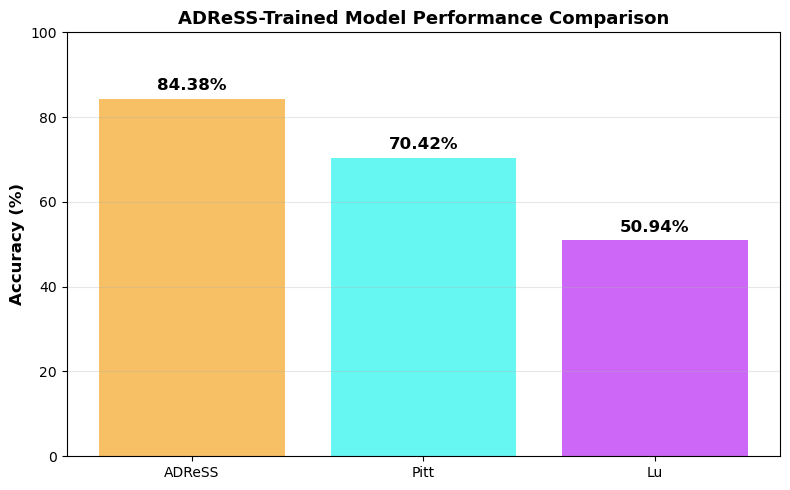


Results Summary:
ADReSS Dataset Accuracy: 84.38% (training set)
Pitt Dataset Accuracy: 70.42%
Lu Dataset Accuracy: 50.94%


In [10]:
# 准备可视化数据
dataset_names = [TRAIN_MODEL] + [r['name'] for r in results]
accuracies = [TRAIN_MODEL_ACC] + [r['accuracy'] * 100 for r in results]

bar_colors = COLORS[:len(dataset_names)]

fig, ax = plt.subplots(figsize=(max(8, len(dataset_names)*2), 5))

ax.bar(dataset_names, accuracies, color=bar_colors, alpha=0.7)
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'{TRAIN_MODEL}-Trained Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(accuracies):
    ax.text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Results Summary:")
print(f"{'='*60}")
print(f"{TRAIN_MODEL} Dataset Accuracy: {TRAIN_MODEL_ACC:.2f}% (training set)")
for result in results:
    print(f"{result['name']} Dataset Accuracy: {result['accuracy']*100:.2f}%")